# Test1 --- individual NLE 

In [1]:
import numpy as np

In [2]:
import torch
from sbi.inference import NPE

In [3]:
import corner as DFM
import matplotlib.pyplot as plt

In [4]:
params = np.loadtxt("/Users/chang/data/px2cosmo/test1/mock1_N50000fdown10.params.dat")[::100]
data = np.loadtxt("/Users/chang/data/px2cosmo/test1/mock1_N50000fdown10.data.dat")[::100]

In [5]:
print(params.shape[0])

1103294


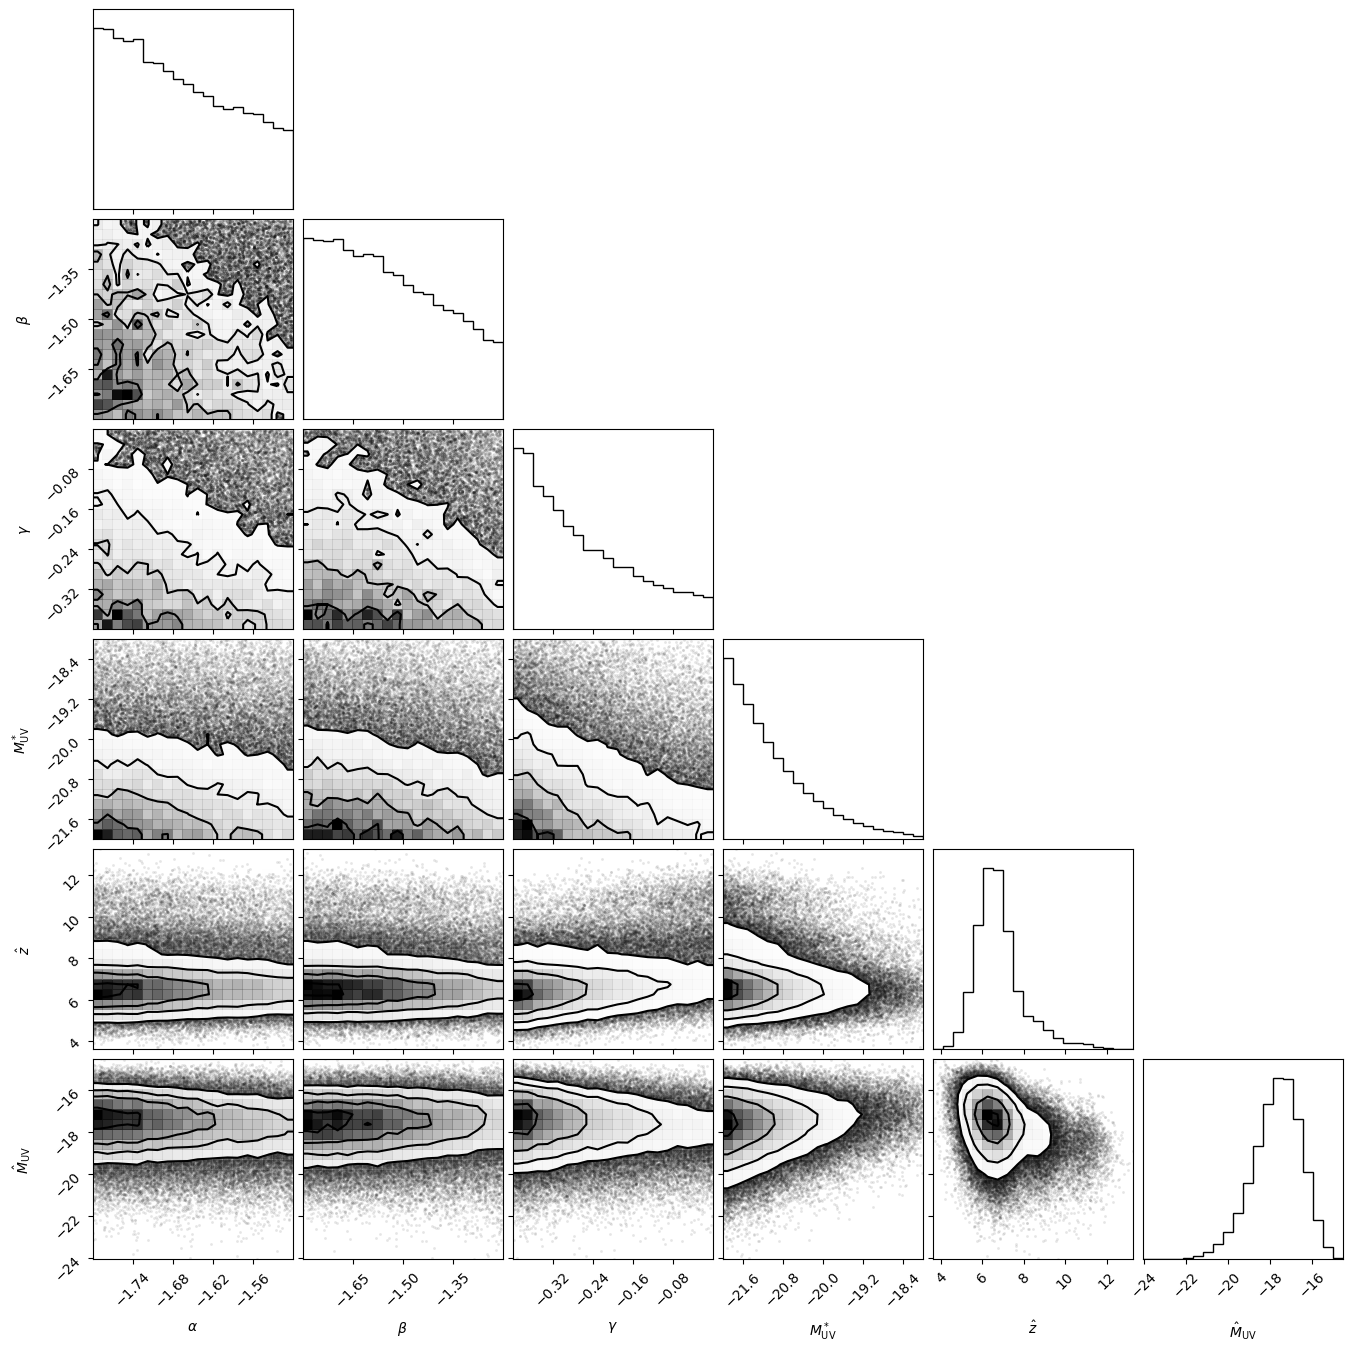

In [6]:
fig = DFM.corner(np.hstack([params, data])[::10], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\hat{z}$', r'$\hat{M}_{\rm UV}$'])

## train NDE

We want to estimate $p(X\,|\,\phi)$

In [7]:
ishuffle = np.arange(params.shape[0])
np.random.shuffle(ishuffle)

In [8]:
_phi = torch.tensor(params[ishuffle][:int(params.shape[0]*0.9)].astype(np.float32))#.to('mps')
_X = torch.tensor(data[ishuffle][:int(params.shape[0]*0.9)].astype(np.float32))#.to('mps')

In [9]:
inference = NPE(density_estimator='zuko_maf')#, device='mps')
_ = inference.append_simulations(_X, _phi).train()

 Neural network successfully converged after 38 epochs.

In [10]:
p_X_phi = inference.build_posterior()

/opt/homebrew/Caskroom/miniconda/base/envs/jwst/lib/python3.14/site-packages/sbi/inference/potentials/posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


## validate NDE

In [11]:
test_phi = torch.tensor(params[ishuffle][int(params.shape[0]*0.9):][::10].astype(np.float32))#.to('mps')
test_X = torch.tensor(data[ishuffle][int(params.shape[0]*0.9):][::10].astype(np.float32))#.to('mps')

  0%|          | 0/10000 [00:00<?, ?it/s]

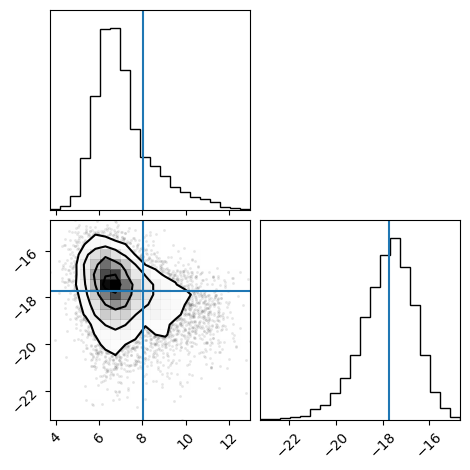

  0%|          | 0/10000 [00:00<?, ?it/s]

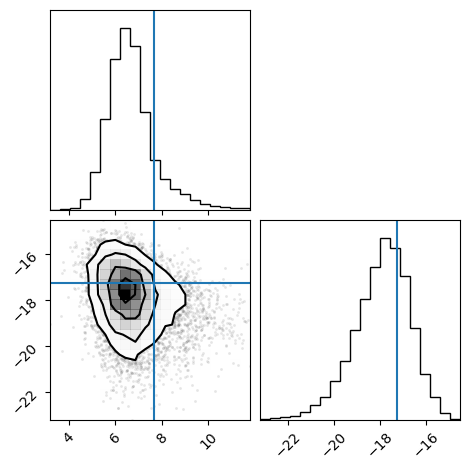

  0%|          | 0/10000 [00:00<?, ?it/s]

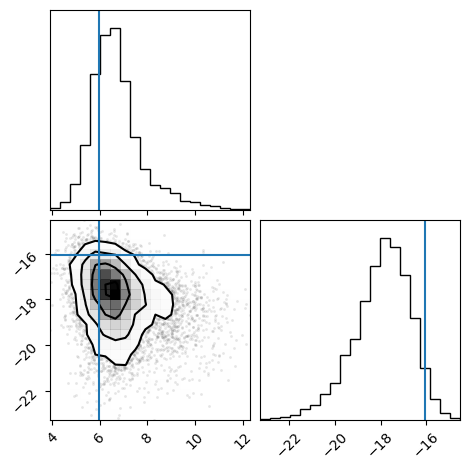

In [12]:
for i in range(3):
    samples = p_X_phi.sample((10000,), x=test_phi[i]).cpu()
    fig = DFM.corner(samples.numpy())
    DFM.overplot_lines(fig, test_X[i].cpu())
    plt.show()

In [13]:
test_samples = p_X_phi.sample_batched((1000,), x=test_phi, show_progress_bars=False)

/var/folders/4_/4m4zwzzs30518t13kpqjy7k80000gn/T/ipykernel_52037/2729307748.py:1: UserWarning: Note that for batched sampling, the direct posterior sampling generates 11033 * 1000 = 11033000 samples. This can be slow and memory-intensive. Consider reducing the number of samples or batch size.
  test_samples = p_X_phi.sample_batched((1000,), x=test_phi, show_progress_bars=False)
/var/folders/4_/4m4zwzzs30518t13kpqjy7k80000gn/T/ipykernel_52037/2729307748.py:1: UserWarning: Capping max_sampling_batch_size from 10000 to 9 to avoid excessive memory usage.
  test_samples = p_X_phi.sample_batched((1000,), x=test_phi, show_progress_bars=False)


In [14]:
import tarp

In [15]:
ecp, alpha = tarp.get_tarp_coverage(test_samples.cpu().numpy(), test_X.cpu().numpy())

Text(0.5, 0, 'Credibility Level')

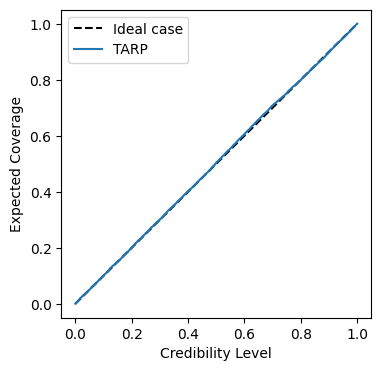

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.plot([0, 1], [0, 1], ls='--', color='k', label = "Ideal case")
ax.plot(alpha, ecp, label='TARP')
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")

# additional tests of the likelihood
comparison directly against forward model

In [17]:
from px2cosmo import fm as FM 
from px2cosmo import util as UT

  0%|          | 0/10000 [00:00<?, ?it/s]

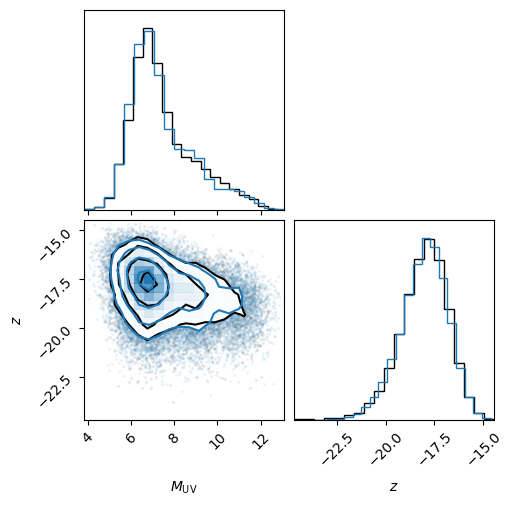

  0%|          | 0/10000 [00:00<?, ?it/s]

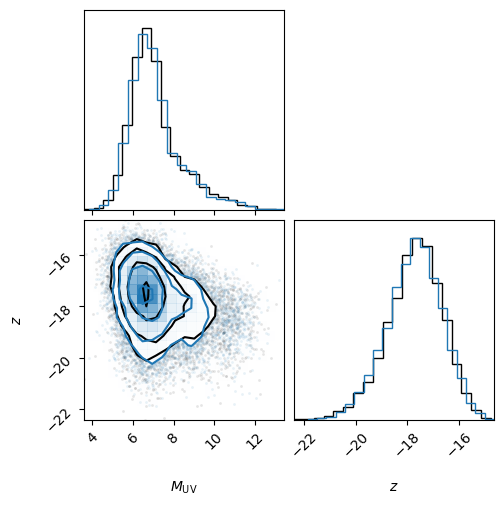

  0%|          | 0/10000 [00:00<?, ?it/s]

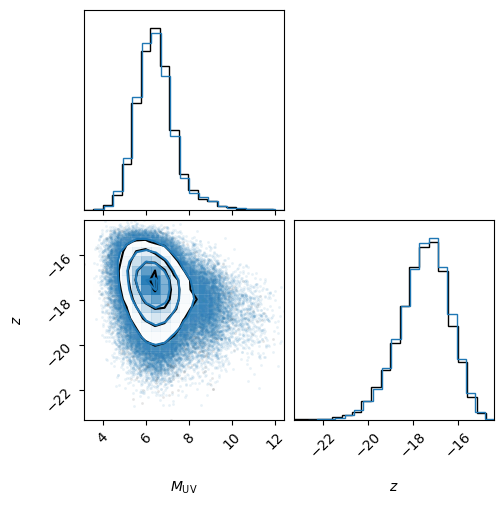

  0%|          | 0/10000 [00:00<?, ?it/s]

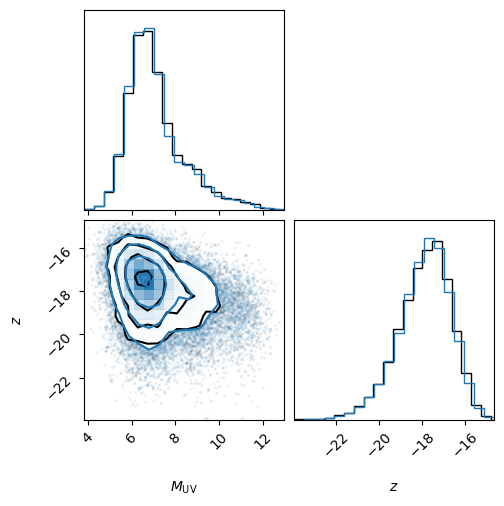

  0%|          | 0/10000 [00:00<?, ?it/s]

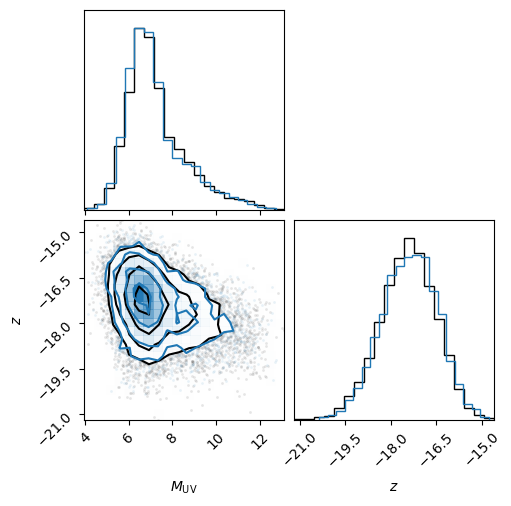

  0%|          | 0/10000 [00:00<?, ?it/s]

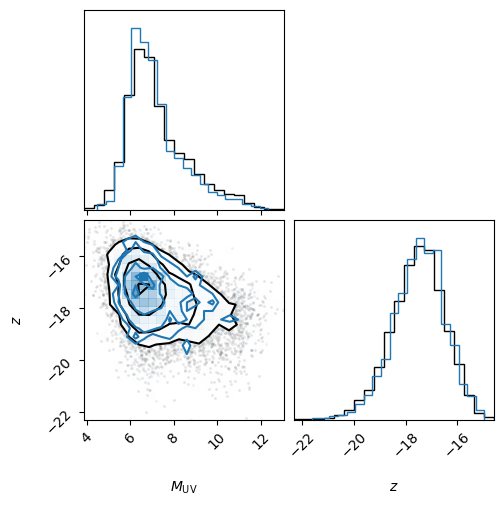

  0%|          | 0/10000 [00:00<?, ?it/s]

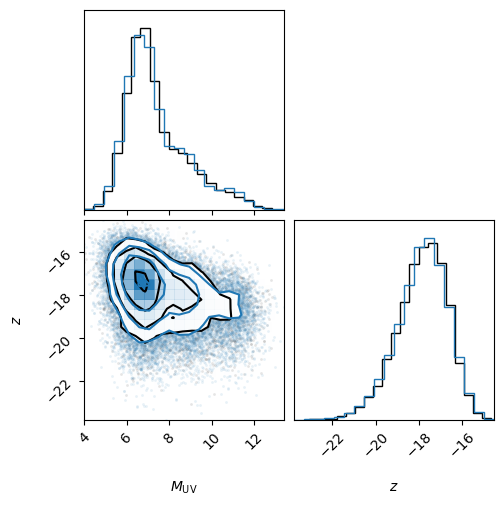

  0%|          | 0/10000 [00:00<?, ?it/s]

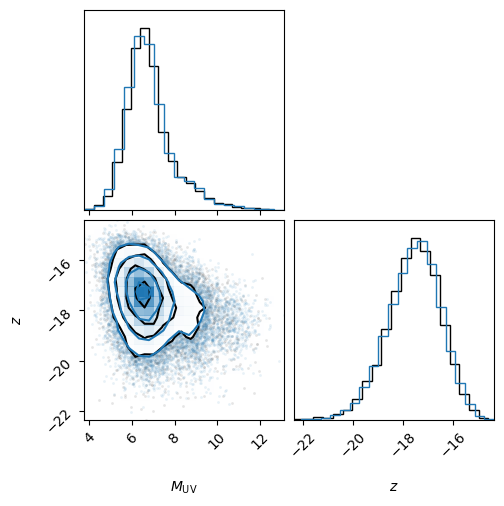

  0%|          | 0/10000 [00:00<?, ?it/s]

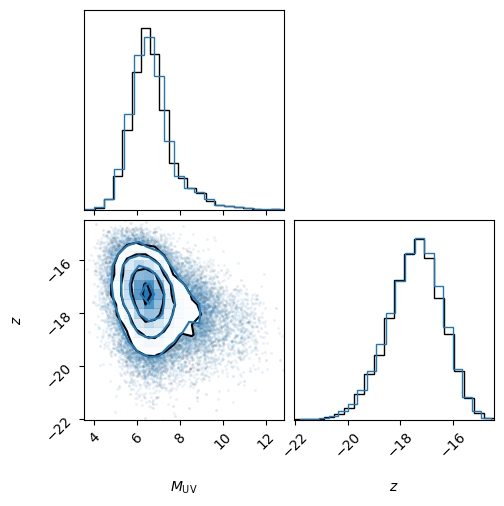

  0%|          | 0/10000 [00:00<?, ?it/s]

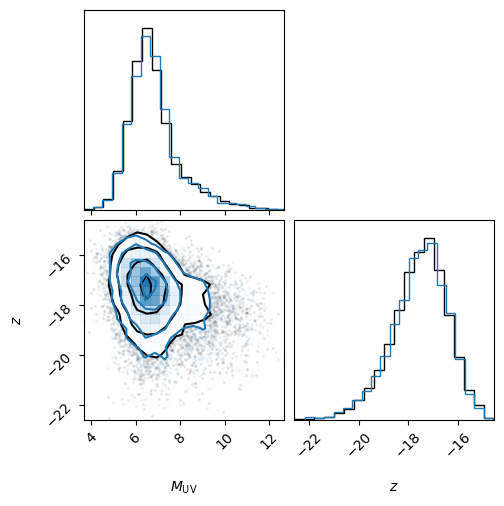

In [25]:
for i in range(10): 
    _alpha = np.random.uniform(-1.8, -1.5) 
    _beta = np.random.uniform(-1.8, -1.2)
    _gamma = np.random.uniform(-0.4, 0.0) 
    _Muv_s = np.random.uniform(-22., -18.)
    _phi = np.array([_alpha, _beta, _gamma, _Muv_s])

    _X = FM.forwardmodel(_phi, name='test1')

    samples = p_X_phi.sample((10000,), x=torch.tensor(_phi.astype(np.float32))).cpu()
    fig = DFM.corner(samples.numpy(), labels=[r"$M_{\rm UV}$", "$z$"], hist_kwargs={'density':True})
    _ = DFM.corner(_X, labels=[r"$M_{\rm UV}$", "$z$"], fig=fig, color='C0', hist_kwargs={'density':True})
    plt.show()

In [23]:
torch.save(p_X_phi, '/Users/chang/data/px2cosmo/test1/mock1_p_X_phi.pt')